# Proyecto B - Clasificación de Imágenes

## README

### Supuestos
- El archivo `train.csv` contiene las columnas `id` (identificador de imagen) y `species` (etiqueta/clase).
- Las imágenes están almacenadas en la carpeta `images/` con el formato `{id}.jpg`.
- Se realizará clasificación multiclase sobre las imágenes.

### Cómo ejecutar
1. Asegúrate de tener instaladas las librerías: `sklearn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `tensorflow`.
2. Ejecuta las celdas en orden secuencial.
3. El notebook procesará las imágenes, aplicará PCA, entrenará tres modelos y mostrará las métricas de evaluación.

### Estructura del flujo
1. **Importaciones**: Librerías necesarias
2. **Carga de datos**: Lectura del CSV y carga de imágenes
3. **Preprocesamiento**: Redimensionamiento, normalización y división de datos
4. **PCA**: Reducción de dimensionalidad sobre vectores de imagen
5. **Entrenamiento**: RandomForest, GradientBoosting y Red Neuronal
6. **Evaluación**: Métricas y visualizaciones
7. **Guardado de resultados**: Exportación de resultados


In [1]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)



2025-11-17 12:25:11.999959: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 12:25:12.189820: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 12:25:12.189883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 12:25:12.216856: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 12:25:12.281712: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 12:25:12.282977: I tensorflow/core/platform/cpu_feature_guard.cc:1

Resumen rápido del dataset
- Total de muestras: 990
- Número de clases: 99
- Columnas relevantes: id (ID) / species (clase)

Clases con más y menos muestras:
species
Acer_Opalus           10
Crataegus_Monogyna    10
Acer_Mono             10
Magnolia_Heptapeta    10
Acer_Capillipes       10
Name: count, dtype: int64
...
species
Alnus_Rubra                    10
Rhododendron_x_Russellianum    10
Cytisus_Battandieri            10
Liriodendron_Tulipifera        10
Sorbus_Aria                    10
Name: count, dtype: int64


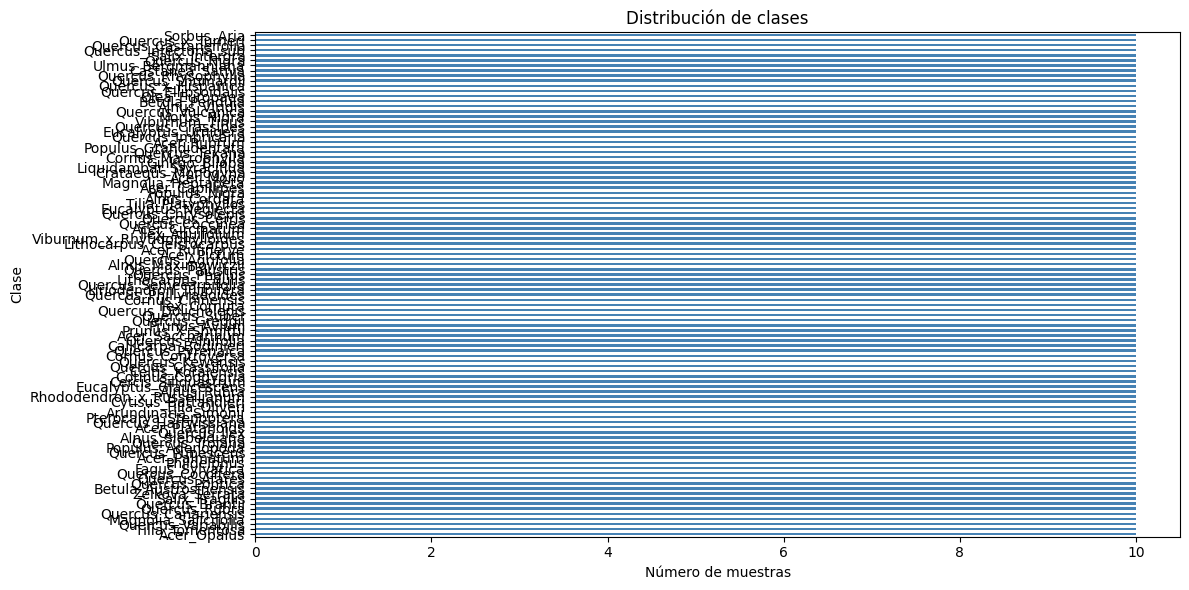

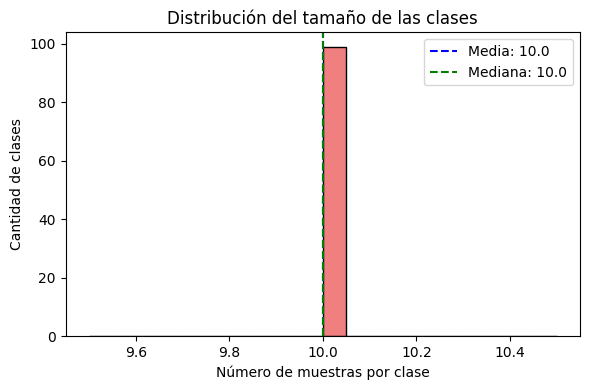


Imágenes en carpeta 'images/': 1584
Hay imágenes suficientes para todas las filas del CSV.


In [ ]:
# Análisis Exploratorio de Datos (EDA)
# Cargar datos para análisis y detectar columnas de ID/etiqueta
df_eda = pd.read_csv('train.csv')
if 'image_id' in df_eda.columns and 'label' in df_eda.columns:
    image_id_col = 'image_id'
    label_col = 'label'
elif 'id' in df_eda.columns and 'species' in df_eda.columns:
    image_id_col = 'id'
    label_col = 'species'
else:
    image_id_col = df_eda.columns[0]
    label_col = df_eda.columns[1]

print("Resumen rápido del dataset")
print(f"- Total de muestras: {len(df_eda)}")
print(f"- Número de clases: {df_eda[label_col].nunique()}")
print(f"- Columnas relevantes: {image_id_col} (ID) / {label_col} (clase)")

# Distribución de clases
class_counts = df_eda[label_col].value_counts()
print("\nClases con más y menos muestras:")
print(class_counts.head())
print("...")
print(class_counts.tail())

# Gráfico de barras de distribución completa
plt.figure(figsize=(12, 6))
class_counts.sort_values().plot(kind='barh', color='steelblue')
plt.title('Distribución de clases')
plt.xlabel('Número de muestras')
plt.ylabel('Clase')
plt.tight_layout()
plt.show()


# Verificar disponibilidad de imágenes
images_dir = 'images/'
if os.path.exists(images_dir):
    total_img = len([f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"\nImágenes en carpeta 'images/': {total_img}")
    if total_img >= len(df_eda):
        print("Hay imágenes suficientes para todas las filas del CSV.")
    else:
        print(f" Faltan {len(df_eda) - total_img} imágenes respecto al CSV.")
else:
    print(" Carpeta 'images/' no encontrada")


In [3]:
# Carga de datos
# Leer el CSV
df = pd.read_csv('train.csv')

# Detectar columnas: id (image_id) y species (label)
# Si existen columnas 'image_id' y 'label', usarlas; si no, usar 'id' y 'species'
if 'image_id' in df.columns and 'label' in df.columns:
    image_id_col = 'image_id'
    label_col = 'label'
elif 'id' in df.columns and 'species' in df.columns:
    image_id_col = 'id'
    label_col = 'species'
else:
    # Buscar columnas que puedan ser el identificador y la etiqueta
    image_id_col = df.columns[0]  # Primera columna como identificador
    label_col = df.columns[1]      # Segunda columna como etiqueta

print(f"Columna de ID de imagen: {image_id_col}")
print(f"Columna de etiqueta: {label_col}")
print(f"\nPrimeras filas del dataset:")
print(df[[image_id_col, label_col]].head())
print(f"\nNúmero de muestras: {len(df)}")
print(f"Número de clases: {df[label_col].nunique()}")
print(f"\nDistribución de clases:")
print(df[label_col].value_counts())


Columna de ID de imagen: id
Columna de etiqueta: species

Primeras filas del dataset:
   id                species
0   1            Acer_Opalus
1   2  Pterocarya_Stenoptera
2   3   Quercus_Hartwissiana
3   5        Tilia_Tomentosa
4   6     Quercus_Variabilis

Número de muestras: 990
Número de clases: 99

Distribución de clases:
species
Acer_Opalus                    10
Crataegus_Monogyna             10
Acer_Mono                      10
Magnolia_Heptapeta             10
Acer_Capillipes                10
                               ..
Alnus_Rubra                    10
Rhododendron_x_Russellianum    10
Cytisus_Battandieri            10
Liriodendron_Tulipifera        10
Sorbus_Aria                    10
Name: count, Length: 99, dtype: int64


In [ ]:
# Preprocesamiento
# Configuración
IMG_SIZE = 128  # Tamaño de redimensionamiento
images_dir = 'images/'

# Función para cargar y preprocesar imágenes usando TensorFlow
def load_and_preprocess_image(img_path, img_size=IMG_SIZE):

    try:
        # Leer archivo de imagen
        img_data = tf.io.read_file(img_path)
        # Decodificar imagen (soporta JPG, PNG, etc.)
        img = tf.image.decode_image(img_data, channels=3)
        # Redimensionar
        img = tf.image.resize(img, [img_size, img_size])
        # Convertir a float32 y normalizar a [0,1]
        img = tf.cast(img, tf.float32) / 255.0
        return img.numpy()
    except Exception as e:
        print(f"Error cargando {img_path}: {e}")
        return None

# Cargar todas las imágenes
image_vectors = []
valid_indices = []
labels = []

for idx, row in df.iterrows():
    img_id = str(row[image_id_col])
    # Intentar diferentes formatos de nombre de archivo
    img_path = os.path.join(images_dir, f"{img_id}.jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(images_dir, f"{img_id}.png")
    
    if os.path.exists(img_path):
        img_array = load_and_preprocess_image(img_path, IMG_SIZE)
        if img_array is not None:
            # Aplanar la imagen: (128, 128, 3) -> (49152,)
            img_flat = img_array.flatten()
            image_vectors.append(img_flat)
            labels.append(row[label_col])
            valid_indices.append(idx)
    else:
        print(f"Imagen no encontrada: {img_path}")

# Convertir a arrays numpy
X = np.array(image_vectors)
y = np.array(labels)

print(f"\nImágenes cargadas: {len(X)}")
print(f"Forma de X: {X.shape}")
print(f"Forma de cada vector de imagen: {X[0].shape}")

# Codificar etiquetas a enteros
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Número de clases: {num_classes}")
print(f"Clases: {label_encoder.classes_[:10]}...")  # Mostrar primeras 10


Cargando imágenes...

Imágenes cargadas: 990
Forma de X: (990, 49152)
Forma de cada vector de imagen: (49152,)
Número de clases: 99
Clases: ['Acer_Capillipes' 'Acer_Circinatum' 'Acer_Mono' 'Acer_Opalus'
 'Acer_Palmatum' 'Acer_Pictum' 'Acer_Platanoids' 'Acer_Rubrum'
 'Acer_Rufinerve' 'Acer_Saccharinum']...


In [ ]:
# División de datos: 70% train, 15% validation, 15% test
# Primero dividir en train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

# Luego dividir temp (30%) en validation (15%) y test (15%)
# De temp (30%), necesitamos 15% del total = 50% de temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


Dimensiones originales: 49152
Dimensiones después de PCA: 312
Varianza explicada: 0.9501
Reducción de dimensionalidad: 99.37%


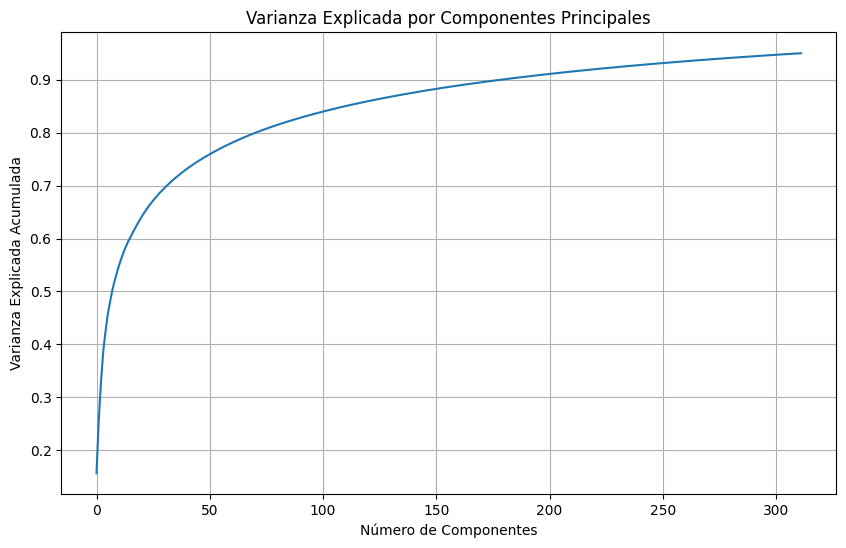

In [6]:
# PCA - Reducción de dimensionalidad
# Aplicar PCA sobre los vectores de imagen aplanados
# Usar suficientes componentes para explicar al menos 95% de la varianza
pca = PCA(n_components=0.95, random_state=42)  # Mantener 95% de varianza

X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Dimensiones originales: {X_train.shape[1]}")
print(f"Dimensiones después de PCA: {X_train_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Reducción de dimensionalidad: {(1 - X_train_pca.shape[1]/X_train.shape[1])*100:.2f}%")

# Visualizar varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Componentes Principales')
plt.grid(True)
plt.show()


In [ ]:
# Entrenamiento de modelos
# Modelo  Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_model.fit(X_train_pca, y_train)
rf_train_pred = rf_model.predict(X_train_pca)
rf_val_pred = rf_model.predict(X_val_pca)
rf_test_pred = rf_model.predict(X_test_pca)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_val_acc = accuracy_score(y_val, rf_val_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print(f"Accuracy en entrenamiento: {rf_train_acc:.4f}")
print(f"Accuracy en validación: {rf_val_acc:.4f}")
print(f"Accuracy en prueba: {rf_test_acc:.4f}")


Accuracy en entrenamiento: 1.0000
Accuracy en validación: 0.4662
Accuracy en prueba: 0.3960


In [ ]:
# Modelo  Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

gb_model.fit(X_train_pca, y_train)
gb_train_pred = gb_model.predict(X_train_pca)
gb_val_pred = gb_model.predict(X_val_pca)
gb_test_pred = gb_model.predict(X_test_pca)

gb_train_acc = accuracy_score(y_train, gb_train_pred)
gb_val_acc = accuracy_score(y_val, gb_val_pred)
gb_test_acc = accuracy_score(y_test, gb_test_pred)

print(f"Accuracy en entrenamiento: {gb_train_acc:.4f}")
print(f"Accuracy en validación: {gb_val_acc:.4f}")
print(f"Accuracy en prueba: {gb_test_acc:.4f}")


Accuracy en entrenamiento: 1.0000
Accuracy en validación: 0.2500
Accuracy en prueba: 0.1879


Epoch 1/50
22/22 [==============================] - 1s 10ms/step - loss: 5.4659 - accuracy: 0.0115 - val_loss: 4.4518 - val_accuracy: 0.0473
Epoch 2/50
22/22 [==============================] - 0s 4ms/step - loss: 4.5349 - accuracy: 0.0346 - val_loss: 4.3373 - val_accuracy: 0.0811
Epoch 3/50
22/22 [==============================] - 0s 4ms/step - loss: 4.2457 - accuracy: 0.0664 - val_loss: 4.1480 - val_accuracy: 0.1554
Epoch 4/50
22/22 [==============================] - 0s 4ms/step - loss: 4.0430 - accuracy: 0.1010 - val_loss: 3.8945 - val_accuracy: 0.2027
Epoch 5/50
22/22 [==============================] - 0s 4ms/step - loss: 3.7914 - accuracy: 0.1472 - val_loss: 3.5748 - val_accuracy: 0.2500
Epoch 6/50
22/22 [==============================] - 0s 4ms/step - loss: 3.3938 - accuracy: 0.2006 - val_loss: 3.2143 - val_accuracy: 0.3243
Epoch 7/50
22/22 [==============================] - 0s 4ms/step - loss: 3.0671 - accuracy: 0.2439 - val_loss: 2.9450 - val_accuracy: 0.3378
Epoch 8/50
22/22 [=

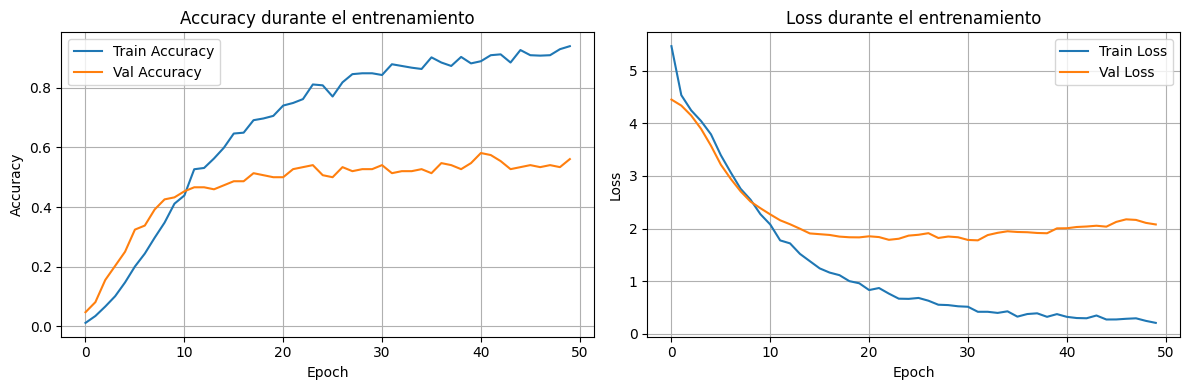

In [ ]:
# Modelo : Red Neuronal con TensorFlow/Keras


# Convertir etiquetas a one-hot encoding para la red neuronal
y_train_onehot = keras.utils.to_categorical(y_train, num_classes)
y_val_onehot = keras.utils.to_categorical(y_val, num_classes)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes)

# Construir el modelo
nn_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

# Compilar el modelo
nn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
history = nn_model.fit(
    X_train_pca, y_train_onehot,
    validation_data=(X_val_pca, y_val_onehot),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Predicciones
nn_train_pred = np.argmax(nn_model.predict(X_train_pca, verbose=0), axis=1)
nn_val_pred = np.argmax(nn_model.predict(X_val_pca, verbose=0), axis=1)
nn_test_pred = np.argmax(nn_model.predict(X_test_pca, verbose=0), axis=1)

nn_train_acc = accuracy_score(y_train, nn_train_pred)
nn_val_acc = accuracy_score(y_val, nn_val_pred)
nn_test_acc = accuracy_score(y_test, nn_test_pred)

print(f"\nAccuracy en entrenamiento: {nn_train_acc:.4f}")
print(f"Accuracy en validación: {nn_val_acc:.4f}")
print(f"Accuracy en prueba: {nn_test_acc:.4f}")

# Visualizar historial de entrenamiento
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


RESUMEN DE RESULTADOS - CONJUNTO DE PRUEBA
              Modelo  Accuracy (Test)
0      Random Forest         0.395973
1  Gradient Boosting         0.187919
2       Red Neuronal         0.503356




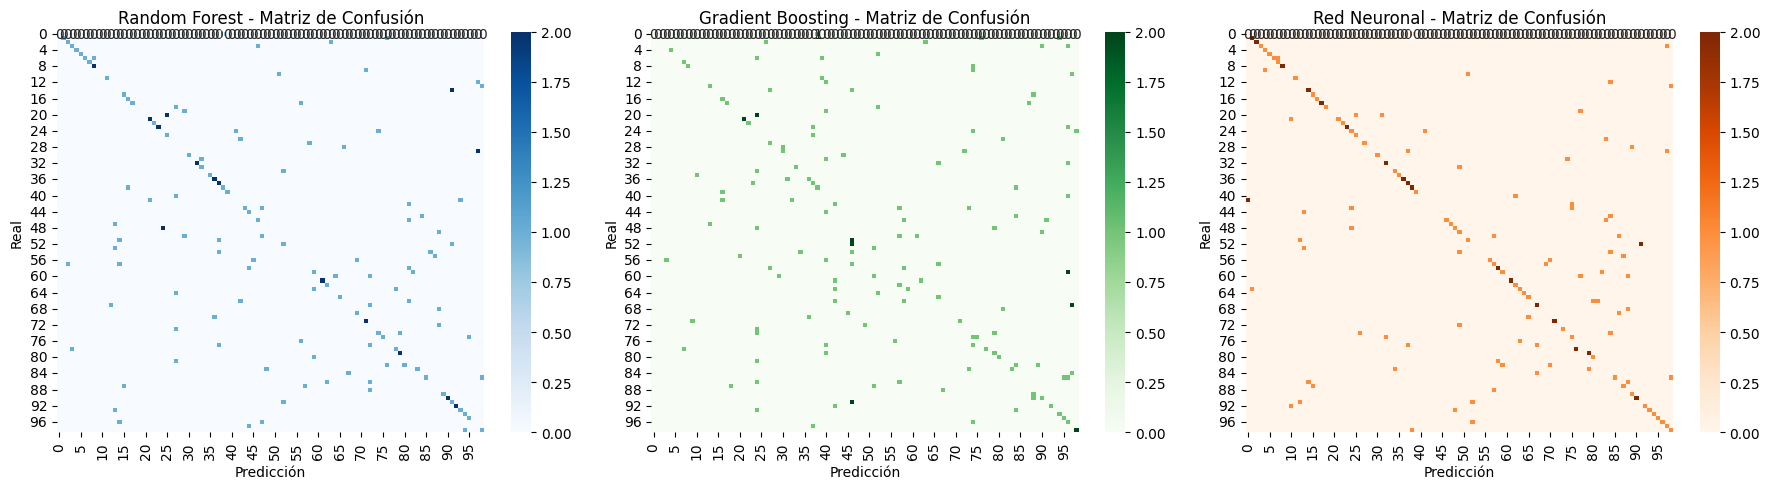

In [10]:
# Evaluación de modelos
# Comparación de accuracy en test

print("RESUMEN DE RESULTADOS - CONJUNTO DE PRUEBA")


results_summary = pd.DataFrame({
    'Modelo': ['Random Forest', 'Gradient Boosting', 'Red Neuronal'],
    'Accuracy (Test)': [rf_test_acc, gb_test_acc, nn_test_acc]
})

print(results_summary)
print("\n")

# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
cm_rf = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Matriz de Confusión')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Gradient Boosting
cm_gb = confusion_matrix(y_test, gb_test_pred)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Gradient Boosting - Matriz de Confusión')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Red Neuronal
cm_nn = confusion_matrix(y_test, nn_test_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Red Neuronal - Matriz de Confusión')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()


In [13]:
# Reportes de clasificación detallados

print("REPORTE DE CLASIFICACIÓN - RANDOM FOREST")
print(classification_report(y_test, rf_test_pred,target_names=label_encoder.classes_))


print("REPORTE DE CLASIFICACIÓN - GRADIENT BOOSTING")

print(classification_report(y_test, gb_test_pred, 
                          target_names=label_encoder.classes_))


print("REPORTE DE CLASIFICACIÓN - RED NEURONAL")

print(classification_report(y_test, nn_test_pred, 
                          target_names=label_encoder.classes_))


REPORTE DE CLASIFICACIÓN - RANDOM FOREST
                              precision    recall  f1-score   support

             Acer_Capillipes       0.00      0.00      0.00         1
             Acer_Circinatum       1.00      0.50      0.67         2
                   Acer_Mono       0.50      0.50      0.50         2
                 Acer_Opalus       0.50      0.50      0.50         2
               Acer_Palmatum       1.00      1.00      1.00         1
                 Acer_Pictum       1.00      1.00      1.00         1
             Acer_Platanoids       1.00      0.50      0.67         2
                 Acer_Rubrum       1.00      1.00      1.00         1
              Acer_Rufinerve       0.67      1.00      0.80         2
            Acer_Saccharinum       0.00      0.00      0.00         1
               Alnus_Cordata       0.00      0.00      0.00         1
          Alnus_Maximowiczii       1.00      1.00      1.00         1
                 Alnus_Rubra       0.00      0.0